In [ ]:
import importlib

# 1. Modul-Import
import sidm_sph_MCMC
# 2. Modul-Reload
importlib.reload(sidm_sph_MCMC)


# Dasselbe für CDM (falls die Funktion dort auch MCMC heißt)
import cdm_sph_MCMC
importlib.reload(cdm_sph_MCMC)


import plots
importlib.reload(plots)

from readData import log_M200_weighted_mean, c_MCR

import emcee

In [2]:
sidm_MCMC = sidm_sph_MCMC.sidm_MCMC
cdm_MCMC = cdm_sph_MCMC.MCMC
corner_plot_sidm = plots.corner_plot_sidm
corner_plot_cdm = plots.corner_plot_cdm

In [4]:
galaxy = "NGC3877"
log_ini_M200, _ = log_M200_weighted_mean(galaxy)
c_ini = c_MCR(10**log_ini_M200)

print(f"Initial guess for log(M200) for {galaxy}: {log_ini_M200}")
print(f"Initial guess for concentration c for {galaxy}: {c_ini}")

Initial guess for log(M200) for NGC3877: 11.442747225602233
Initial guess for concentration c for NGC3877: 9.482604298436064


In [41]:
sidm_MCMC(   
    galaxy,
    nwalkers=16,
    nsteps=100,
    initial_r1=10.0,
    resume=True,
    start_logM=log_ini_M200,
    c_start=c_ini,
    initial_volume=0.1,
    savename="sidm",
    num_cores = 8,)

Files saved as: sidm_NGC3877_nw_16.h5
Data for NGC3877 could be loaded.
Resume MCMC for NGC3877...


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [18:07<00:00, 10.87s/it]

MCMC ended. Endnumber of Backends iterations: 600


In [42]:
path = "chains/"
filename = path + f"sidm_{galaxy}_nw_16.h5"

reader = emcee.backends.HDFBackend(filename)
print("Iterations:", reader.iteration)

Iterations: 600


In [8]:
blobs = reader.get_blobs()
xs = blobs["cross-section"]
print("Cross-sections:", xs[0])

vrels = blobs["vrel"]
print("Relative velocities:", vrels[0])

Cross-sections: [0.55631623 0.56742    0.58477896 0.7131721  0.94845842 0.31124716
 0.70868202 0.60156005 0.83290807 0.96326817 0.63400984 0.61768341
 0.62576065 0.89569073 1.02370383 0.89940606]
Relative velocities: [253.0839244  252.04733471 246.38360561 240.52757044 227.76464604
 278.79297286 238.35743987 248.29605257 230.1485131  222.70731766
 242.87496882 241.1727957  242.43916173 226.88445853 224.57022815
 229.38416949]


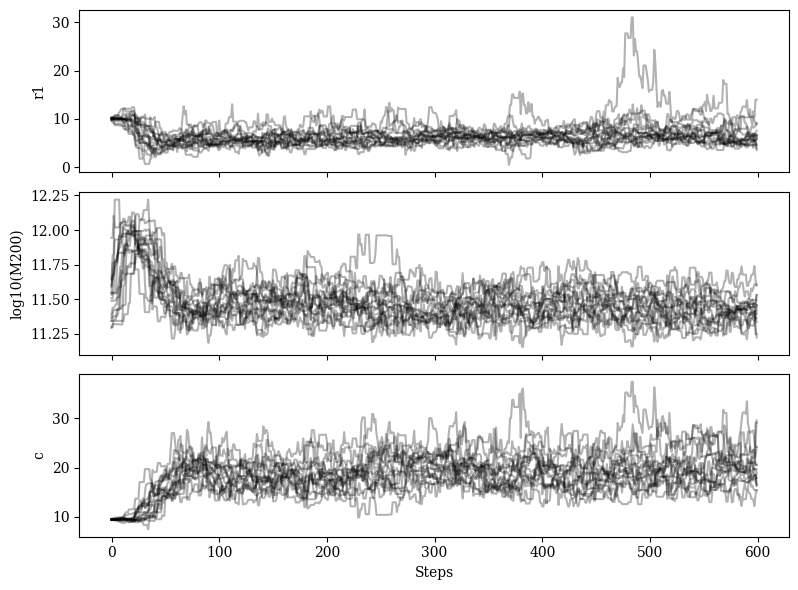

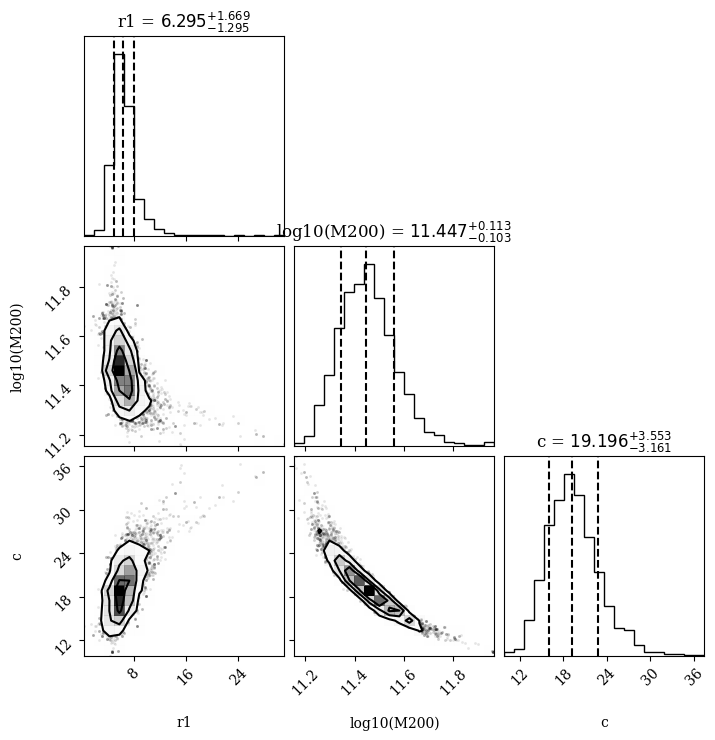

In [43]:
corner_plot_sidm(f'sidm_{galaxy}_nw_16.h5')

Reading MCMC chain with 600 iterations
Discarding 90 iterations as burn-in
Number of recommended iterations: 2265


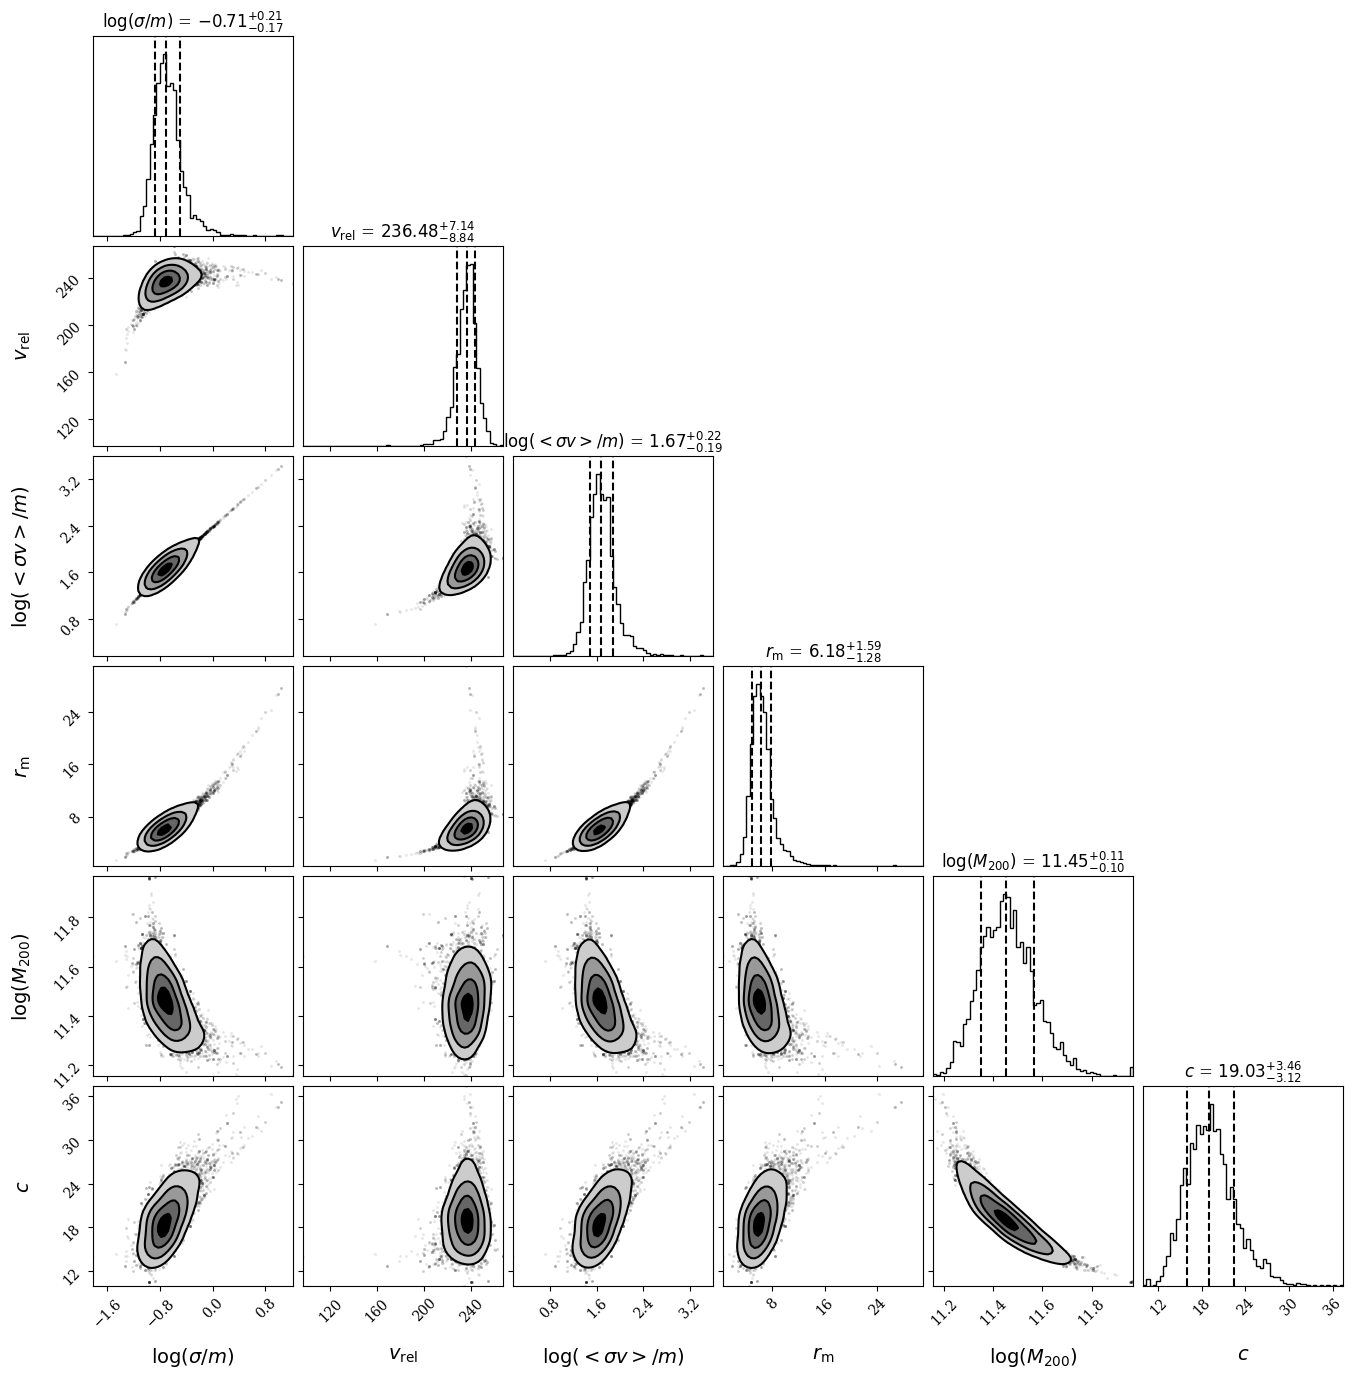

In [44]:
import numpy as np 
import corner 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

def corner_plot(filename):
    
    reader = emcee.backends.HDFBackend(filename)

    niter = reader.iteration
    print(f'Reading MCMC chain with {niter} iterations')

    tau = reader.get_autocorr_time(tol=0)
    burnin = int(2 * np.max(tau))
    print(f'Discarding {burnin} iterations as burn-in')
    # check autocorrelation time and burn-in
    # condition: N > 50 * tau, where N is the number of iterations after burn-in
    lim = int(50 * np.max(tau))
    print(f'Number of recommended iterations: {lim}')
    if niter > lim:
        print(f'Number of iterations after burn-in is sufficient for reliable estimates (N > 50 * tau)')
    else:
        print(f'Warning: Number of iterations after burn-in may be insufficient for reliable estimates (N <= 50 * tau)')

    chain = reader.get_chain(discard=burnin)
    blobs = reader.get_blobs(discard=burnin)
    sigma = blobs["cross-section"][..., None] # extend the array
    vrel = blobs["vrel"][..., None] # extend the array
    sigmavm = sigma * vrel

    full_chain = np.concatenate([np.log10(sigma), vrel, np.log10(sigmavm), chain], axis=-1) 

    flat_chain = full_chain.reshape(-1, full_chain.shape[-1])
    labels = [r'$\log(\sigma/m)$', r'$v_{\rm rel}$', r'$\log(<\sigma v>/m)$', r'$r_{\rm m}$', r'$\log(M_{200})$', r'$c$']

    nwalkers = chain.shape[1]
    
    CORNER_KWARGS = dict(
        bins=60,
        color='k',
        smooth=2.0,
        label_kwargs=dict(fontsize=14),
        title_kwargs=dict(fontsize=12),
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        density=True,
        plot_datapoints=True,
        fill_contours=True, 
        plot_density=True,
        alpha=0.5,
        # truths=truths,
#         levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
#         plot_density=False,
#         plot_datapoints=False,
#         fill_contours=True,
#         max_n_ticks=3,
        title_fmt=".2f"
    )
    fig = corner.corner(flat_chain, labels=labels, **CORNER_KWARGS)
    # fig.subplots_adjust(right=1.5,top=1.5)
    plt.show()
    plt.close(fig)

    return None

corner_plot(filename)

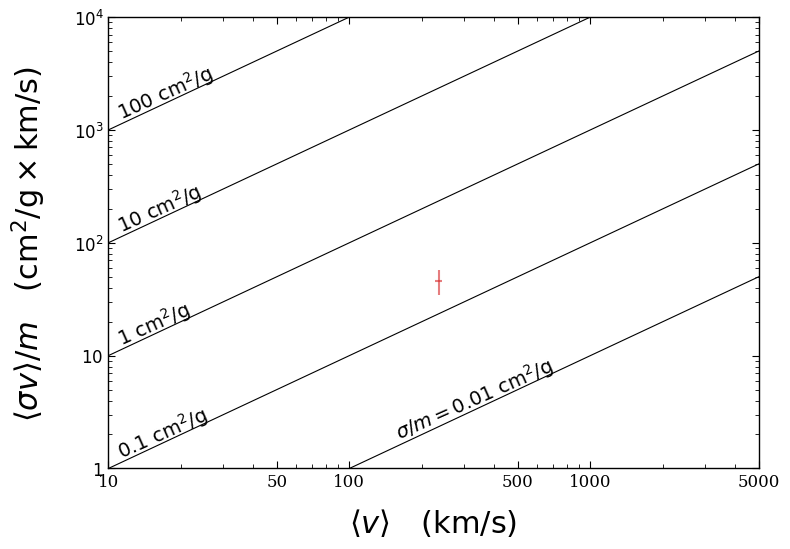

In [55]:
# --- Figure setup ---
fig, ax = plt.subplots(figsize=(8, 5.6))

# Log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Axis limits
ax.set_xlim(10, 5000)
ax.set_ylim(1, 1e4)

# --- Constant sigma/m lines ---
# Since y = <sigma v>/m and x = <v>, lines of constant sigma/m satisfy
# y = (sigma/m) * x
x = np.logspace(np.log10(10), np.log10(5000), 500)

sigmas = [0.01, 0.1, 1, 10, 100]
for s in sigmas:
    ax.plot(x, s * x, color="black", lw=0.8)
    
# plot data points 
vrel = 236.33
vrel_upper = 6.97 
vrel_lower = 9.1 

sigvm = 10**1.66
sigvm_upper = 10**(0.21) + 10
sigvm_lower = 10**(0.19) + 10

plt.errorbar(vrel, sigvm, xerr=[[vrel_lower], [vrel_upper]], yerr=[[sigvm_lower], [sigvm_upper]], fmt='o', color='C3', label='NGC3877', ms=0, alpha=0.6)

# --- Ticks to match the style in the figure ---
ax.set_xticks([10, 50, 100, 500, 1000, 5000])
ax.set_xticklabels(["10", "50", "100", "500", "1000", "5000"], fontsize=12)

ax.set_yticks([1, 10, 100, 1000, 10000])
ax.set_yticklabels([r"$1$", r"$10$", r"$10^2$", r"$10^3$", r"$10^4$"], fontsize=12)

# Minor ticks on, ticks on all sides
ax.minorticks_on()
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.tick_params(which="major", length=5)
ax.tick_params(which="minor", length=3)

# --- Axis labels ---
ax.set_xlabel(r"$\langle v \rangle \quad (\mathrm{km/s})$", fontsize=22, labelpad=12)
ax.set_ylabel(r"$\langle \sigma v \rangle / m \quad (\mathrm{cm^2/g}\times \mathrm{km/s})$",
              fontsize=22, labelpad=18)

# --- Text labels on the diagonal lines ---
rotation = 24  # visually close to the original

ax.text(10.5, 1.25e3, r"$100\ \mathrm{cm^2/g}$", rotation=rotation, fontsize=14)
ax.text(10.5, 1.25e2, r"$10\ \mathrm{cm^2/g}$", rotation=rotation, fontsize=14)
ax.text(10.5, 1.25e1, r"$1\ \mathrm{cm^2/g}$", rotation=rotation, fontsize=14)
ax.text(10.5, 1.25,   r"$0.1\ \mathrm{cm^2/g}$", rotation=rotation, fontsize=14)

# Bottom-center label for 0.01 cm^2/g line
ax.text(150, 1.85, r"$\sigma/m = 0.01\ \mathrm{cm^2/g}$", rotation=rotation, fontsize=14)

# Frame thickness similar to the figure
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()

In [49]:
10**1.66

45.708818961487495

In [12]:

cdm_MCMC(   
    'DDO154',
    nwalkers=16,
    nsteps=10,
    resume=True,
    start_logM=12.0,
    c_start=10.0,
    initial_volume=0.1,
    savename="cdm_Test",
    num_cores = 8,)

Files saved as: cdm_Test_DDO154_nw_16.h5
Data for DDO154 could be loaded.
Resume MCMC for DDO154...


100%|██████████| 10/10 [00:05<00:00,  1.78it/s]

MCMC ended. Endnumber of Backends iterations: 15


In [13]:
path = "chains/"
filename = path + "cdm_Test_DDO154_nw_16.h5"

reader = emcee.backends.HDFBackend(filename)
print("Iterations:", reader.iteration)

Iterations: 15


In [ ]:
# plot 
corner_plot_sidm/cdm(full_filename)

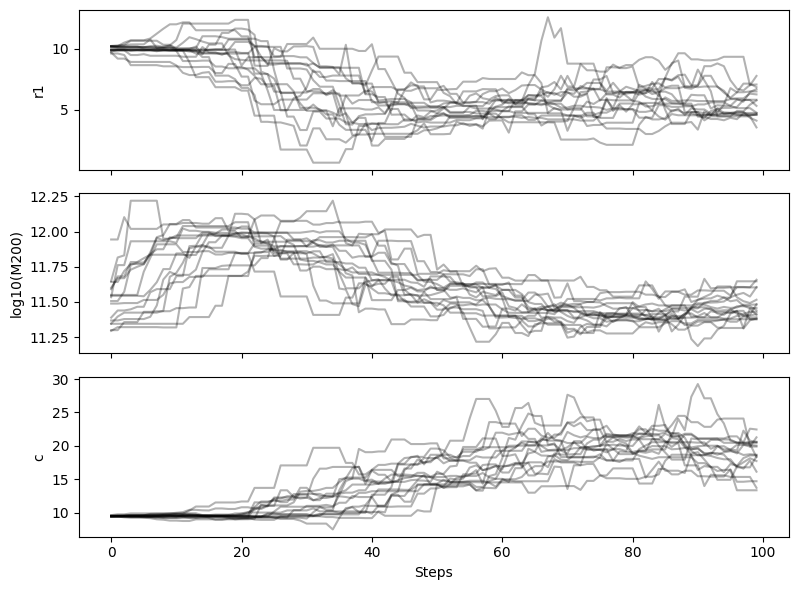

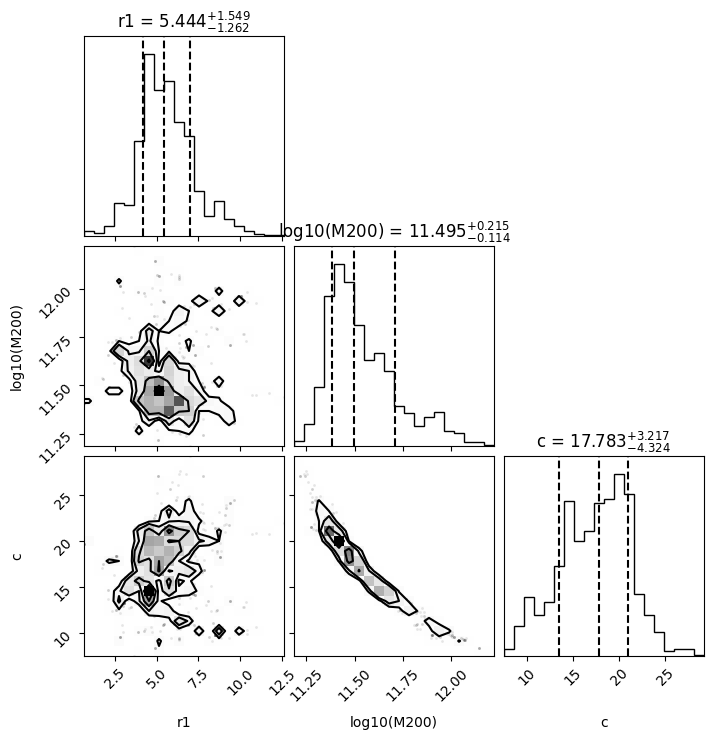

In [9]:
corner_plot_sidm(f'sidm_{galaxy}_nw_16.h5')

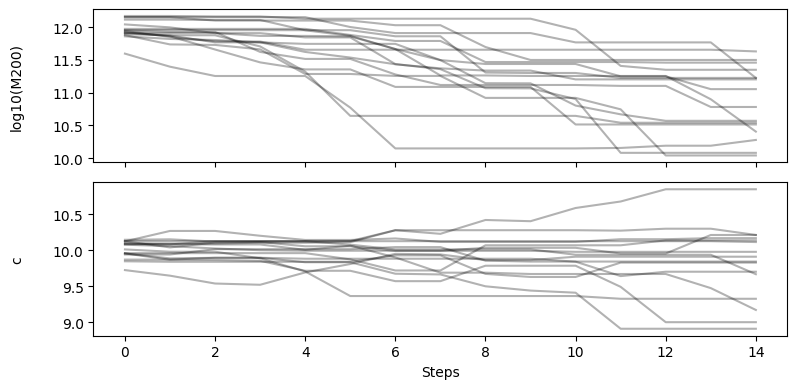

Generating CDM corner plot for 2 parameters...


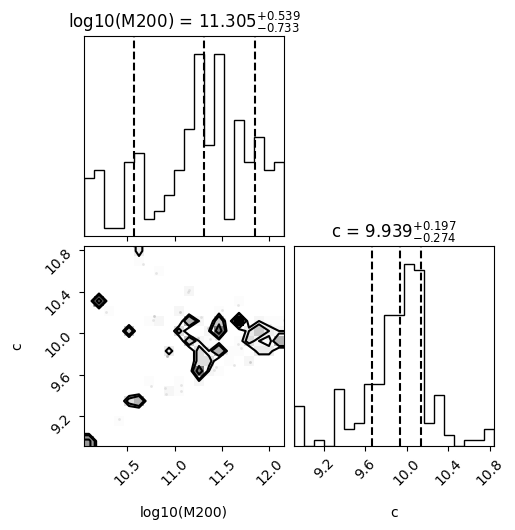

In [15]:
corner_plot_cdm('cdm_Test_DDO154_nw_16.h5')